# Trabajo Práctico: Análisis Estadístico de Educación Superior (Región de Coquimbo 2021)
## Ítem 1: Análisis Descriptivo General

**Integrantes:** Grupo de Trabajo  
**Asignatura:** Estadística Aplicada (MAT4141)  
**Base de Datos:** Matrículas Educación Superior Región de Coquimbo 2021  

En este cuaderno desarrollamos el **Ítem 1**, realizando un análisis exploratorio y descriptivo de las variables más representativas de la base de datos:
- **Variables Cualitativas:** TIPO DE INSTITUCION y GENERO.
- **Análisis Bivariado:** Tabla cruzada entre Tipo de Institución y Género.
- **Variables Cuantitativas:** EDAD y VALOR ARANCEL (PESOS).
- **Estadígrafos:** Medidas de tendencia central (media, mediana, moda), posición (cuartiles Q1, Q3, percentiles) y dispersión (desviación estándar, varianza, rango intercuartílico IQR y coeficiente de variación CV).
- **Gráficos:** Gráficos de barras, circulares e histogramas por intervalos, siguiendo estrictamente el estilo visto en clases.


### Paso 0: Carga de Bibliotecas y Base de Datos


In [1]:
# Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import os

# Creación de DataFrame (DF)
# Verificamos la ruta del archivo ya sea en Colab o en carpeta local
ruta = '05_MATRICULAS_ED_SUPERIOR_COQUIMBO_2021.xlsx'
if not os.path.exists(ruta):
    ruta = 'data/05_MATRICULAS_ED_SUPERIOR_COQUIMBO_2021.xlsx'
if not os.path.exists(ruta):
    ruta = '../data/05_MATRICULAS_ED_SUPERIOR_COQUIMBO_2021.xlsx'

df = pd.read_excel(ruta)
df.head(5)


,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,AÑOS DE ACREDITACION,NOMBRE CARRERA,REQUISITO INGRESO,VIA DE INGRESO,MODALIDAD,JORNADA,TIPO PLAN CARRERA,NIVEL DE ESTUDIO CARRERA,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,227,Masculino,24,20 a 24,2018,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LA SERENA,ACREDITADA,20/12/2016 AL 20/12/2020,4.0,INGENIERIA DE MINAS,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Tecnologia,8,0,8,169400,3181000,Coquimbo,Elqui,La Serena
1,271,Masculino,26,25 a 29,2019,Primer semestre,Centros de Formacion Tecnica,CFT SANTO TOMAS,ACREDITADA,20/12/2019 AL 20/12/2024,5.0,TOPOGRAFIA,Educacion Media,Ingreso Directo (regular),Presencial,Vespertino,Plan Regular,Pregrado,Carreras Tecnicas,Tecnologia,5,0,5,64000,1522000,Coquimbo,Limari,Ovalle
2,294,Masculino,22,20 a 24,2019,Primer semestre,Centros de Formacion Tecnica,CFT SANTO TOMAS,ACREDITADA,20/12/2019 AL 20/12/2024,5.0,TECNICO EN ADMINISTRACION,Educacion Media,Ingreso Directo (regular),Presencial,Vespertino,Plan Regular,Pregrado,Carreras Tecnicas,Administracion y Comercio,5,0,5,64000,1405000,Coquimbo,Limari,Ovalle
3,295,Femenino,22,20 a 24,2020,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,4.0,ENFERMERIA,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Salud,10,0,10,134000,3521000,Coquimbo,Elqui,La Serena
4,301,Masculino,23,20 a 24,2017,Primer semestre,Centros de Formacion Tecnica,CFT INACAP,ACREDITADA,05/01/2018 AL 05/01/2025,7.0,LOGISTICA Y OPERACIONES INDUSTRIALES,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Tecnicas,Administracion y Comercio,4,0,4,250000,2200000,Coquimbo,Elqui,La Serena


In [2]:
# Tamaño de la muestra
muestra = df.shape[0] # Número de filas
muestra


37323

**Interpretación:**  
La base de datos contiene un total de **37.323 estudiantes matriculados** en instituciones de educación superior de la Región de Coquimbo durante el año 2021. Este valor corresponde al tamaño total de la muestra ( = 37.323$).


---
### 1. Variable Cualitativa Nominal: Tipo de Institución
Analizamos cómo se distribuye la matrícula según el tipo de casa de estudios: Universidades del Consejo de Rectores (CRUCH), Institutos Profesionales (IP), Centros de Formación Técnica (CFT) y Universidades Privadas.


In [3]:
# Frecuencia absoluta
cuenta_institucion = df.groupby('TIPO DE INSTITUCION').size()

# Creación de DF con frecuencias absolutas y relativas
tabla_institucion = pd.DataFrame({
    'Frecuencia absoluta': cuenta_institucion,
    'Frecuencia relativa (%)': round(cuenta_institucion / muestra * 100, 1)
})

# Ordenamos de mayor a menor y mostramos la tabla
tabla_institucion = tabla_institucion.sort_values('Frecuencia absoluta', ascending=False)
tabla_institucion


,Frecuencia absoluta,Frecuencia relativa (%)
TIPO DE INSTITUCION,,
Universidades CRUCH,10303,27.6
Institutos Profesionales,10179,27.3
Centros de Formacion Tecnica,8478,22.7
Universidades Privadas,8363,22.4


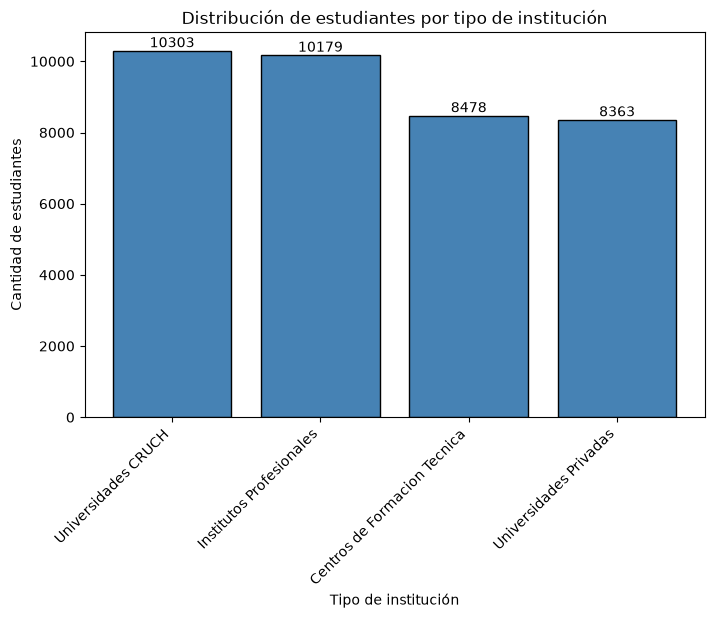

In [4]:
# Variables
categorias_inst = tabla_institucion.index
f_inst = tabla_institucion['Frecuencia absoluta']

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
barras_inst = ax.bar(categorias_inst, f_inst, color='steelblue', edgecolor='black')

# Personalización
ax.set_title('Distribución de estudiantes por tipo de institución')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Cantidad de estudiantes')
ax.bar_label(barras_inst)
plt.xticks(rotation=45, ha='right') # Rota las categorías a 45 grados para evitar superposición

plt.show()


**Comentario e Interpretación:**  
- Las **Universidades CRUCH** concentran la mayor matrícula regional con **10.303 estudiantes (27,6%)**, seguidas muy de cerca por los **Institutos Profesionales (IP)** con **10.179 estudiantes (27,3%)**.
- Los **Centros de Formación Técnica (CFT)** registran **8.478 matriculados (22,7%)** y las **Universidades Privadas** **8.363 matriculados (22,4%)**.
- Se observa una distribución bastante equilibrada entre el subsistema universitario (50,0% sumando CRUCH y Privadas) y el subsistema técnico-profesional IP/CFT (50,0%), lo que refleja la fuerte presencia de educación técnica en la región de Coquimbo.


---
### 2. Variable Cualitativa Nominal: Género
Analizamos la distribución de género de los estudiantes matriculados en la región.


In [5]:
# Frecuencia absoluta
cuenta_genero = df.groupby('GENERO').size()

# Creación de DF con frecuencias absolutas y relativas
tabla_genero = pd.DataFrame({
    'Frecuencia absoluta': cuenta_genero,
    'Frecuencia relativa (%)': round(cuenta_genero / muestra * 100, 1)
})

tabla_genero


,Frecuencia absoluta,Frecuencia relativa (%)
GENERO,,
Femenino,20549,55.1
Masculino,16774,44.9


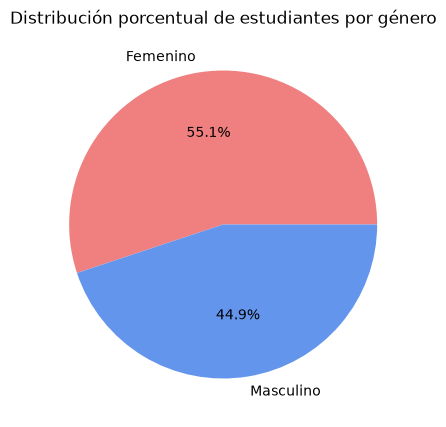

In [6]:
# Variables
categorias_gen = tabla_genero.index
h_gen = tabla_genero['Frecuencia relativa (%)']

# Gráfico
fig, ax = plt.subplots(figsize=(6, 5))
circular_gen = ax.pie(h_gen, labels=categorias_gen, autopct='%.1f%%', colors=['lightcoral', 'cornflowerblue'])

# Personalización
ax.set_title('Distribución porcentual de estudiantes por género')

plt.show()


**Comentario e Interpretación:**  
- De los 37.323 estudiantes, **20.549 son mujeres (55,1%)** y **16.774 son hombres (44,9%)**.
- Existe una mayoría femenina con una diferencia de aproximadamente **10,2 puntos porcentuales** sobre los hombres, lo que concuerda con la tendencia nacional donde las mujeres tienen mayor participación en la matrícula de educación superior.


---
### 3. Tabla Bivariada: Tipo de Institución según Género
Construimos una tabla de contingencia cruzando dos variables cualitativas para ver la composición de género en cada tipo de institución.


In [7]:
# Tabla cruzada de frecuencias absolutas
tabla_cruzada = pd.crosstab(df['TIPO DE INSTITUCION'], df['GENERO'])
tabla_cruzada


GENERO,Femenino,Masculino
TIPO DE INSTITUCION,,
Centros de Formacion Tecnica,3942,4536
Institutos Profesionales,6220,3959
Universidades CRUCH,5239,5064
Universidades Privadas,5148,3215


In [8]:
# Tabla cruzada en porcentaje por fila (proporción dentro de cada institución)
tabla_cruzada_pct = round(pd.crosstab(df['TIPO DE INSTITUCION'], df['GENERO'], normalize='index') * 100, 1)
tabla_cruzada_pct


GENERO,Femenino,Masculino
TIPO DE INSTITUCION,,
Centros de Formacion Tecnica,46.5,53.5
Institutos Profesionales,61.1,38.9
Universidades CRUCH,50.8,49.2
Universidades Privadas,61.6,38.4


**Comentario e Interpretación:**  
- En los **Institutos Profesionales (IP)** y las **Universidades Privadas**, la participación femenina es especialmente alta (**61,1%** y **61,6%** de mujeres respectivamente).
- En cambio, en los **Centros de Formación Técnica (CFT)** predomina el género masculino con un **53,5%** (4.536 hombres vs. 3.942 mujeres), asociado a carreras técnicas de áreas industriales, minería y mecánica que históricamente concentran mayor matrícula masculina en la región.
- En las **Universidades CRUCH**, la distribución es prácticamente paritaria (**50,8% mujeres** vs **49,2% hombres**).


---
### 4. Variable Cuantitativa: Edad de los Estudiantes
Analizamos la variable EDAD, construyendo una tabla de frecuencias agrupada en 10 intervalos de clase, su histograma y las medidas de tendencia central, posición y dispersión.


In [9]:
# Crearemos una nueva columna llamada Intervalos_edad con 10 intervalos
df['Intervalos_edad'] = pd.cut(df['EDAD'], bins=10, include_lowest=True, precision=0)

# Frecuencia absoluta usando observed=True para compatibilidad
cuenta_edad = df.groupby('Intervalos_edad', observed=True).size()

# Tabla de frecuencias completa (absoluta, acumulada, relativa y relativa acumulada)
tabla_edad = pd.DataFrame({
    'Frecuencia absoluta': cuenta_edad,
    'Frecuencia absoluta acumulada': cuenta_edad.cumsum(),
    'Frecuencia relativa (%)': round(cuenta_edad / muestra * 100, 1),
    'Frecuencia relativa acumulada (%)': round((cuenta_edad / muestra * 100).cumsum(), 1)
})

tabla_edad


,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
Intervalos_edad,,,,
"(16.0, 22.0]",18689,18689,50.1,50.1
"(22.0, 27.0]",11246,29935,30.1,80.2
"(27.0, 32.0]",3691,33626,9.9,90.1
"(32.0, 37.0]",1750,35376,4.7,94.8
"(37.0, 42.0]",929,36305,2.5,97.3
"(42.0, 48.0]",565,36870,1.5,98.8
"(48.0, 53.0]",262,37132,0.7,99.5
"(53.0, 58.0]",133,37265,0.4,99.8
"(58.0, 63.0]",48,37313,0.1,100.0


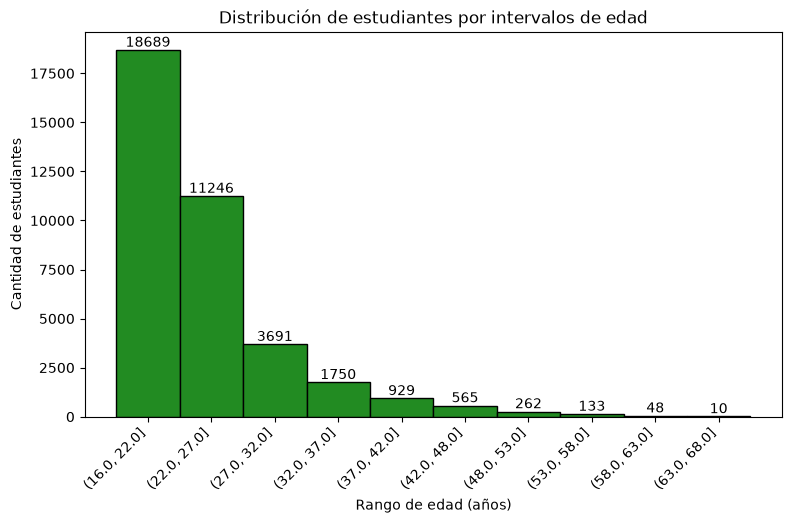

In [10]:
# Variables
categorias_edad = tabla_edad.index
f_edad = tabla_edad['Frecuencia absoluta']

# Gráfico (Histograma con width=1)
fig, ax = plt.subplots(figsize=(9, 5))
histograma_edad = ax.bar(categorias_edad.astype(str), f_edad, color='forestgreen', edgecolor='black', width=1)

# Personalización
ax.set_title('Distribución de estudiantes por intervalos de edad')
ax.set_xlabel('Rango de edad (años)')
ax.set_ylabel('Cantidad de estudiantes')
ax.bar_label(histograma_edad)
plt.xticks(rotation=45, ha='right')

plt.show()


In [11]:
# Cálculo de medidas de tendencia central
media_edad = round(df['EDAD'].mean(), 1)
mediana_edad = round(df['EDAD'].median(), 1)
moda_edad = int(df['EDAD'].mode()[0])

# Medidas de dispersión y posición
desv_edad = round(df['EDAD'].std(), 1)
var_edad = round(df['EDAD'].var(), 1)
q1_edad = round(df['EDAD'].quantile(0.25), 1)
q3_edad = round(df['EDAD'].quantile(0.75), 1)
iqr_edad = round(q3_edad - q1_edad, 1)
cv_edad = round((desv_edad / media_edad) * 100, 1)

# Resumen de estadígrafos de la edad
resumen_edad = pd.DataFrame({
    'Medida estadística': [
        'Media (Promedio)',
        'Mediana',
        'Moda',
        'Primer Cuartil (Q1 - 25%)',
        'Tercer Cuartil (Q3 - 75%)',
        'Rango Intercuartílico (IQR)',
        'Desviación Estándar',
        'Varianza',
        'Coeficiente de Variación (CV %)'
    ],
    'Valor': [
        f'{media_edad} años',
        f'{mediana_edad} años',
        f'{moda_edad} años',
        f'{q1_edad} años',
        f'{q3_edad} años',
        f'{iqr_edad} años',
        f'{desv_edad} años',
        f'{var_edad} años²',
        f'{cv_edad}%'
    ]
})

resumen_edad


,Medida estadística,Valor
0,Media (Promedio),24.3 años
1,Mediana,22.0 años
2,Moda,19 años
3,Primer Cuartil (Q1 - 25%),20.0 años
4,Tercer Cuartil (Q3 - 75%),26.0 años
5,Rango Intercuartílico (IQR),6.0 años
6,Desviación Estándar,6.3 años
7,Varianza,40.1 años²
8,Coeficiente de Variación (CV %),25.9%


**Comentario e Interpretación de los Estadígrafos de Edad:**  
- **Tendencia central:** La **media** es de **24,3 años**, la **mediana** es de **22,0 años** y la **moda** es de **19 años**. Como la media es mayor que la mediana, la distribución de edad presenta una **asimetría positiva (sesgo a la derecha)**; esto se debe a que la mayoría de los estudiantes entra joven recién egresado de enseñanza media, pero existen estudiantes adultos de hasta 68 años que elevan el promedio.
- **Medidas de posición:** 
  - El 25% de los estudiantes más jóvenes tiene **20 años o menos ( = 20$)**.
  - El 50% de los estudiantes tiene **22 años o menos (Mediana = 22)**.
  - El 75% de los estudiantes tiene **26 años o menos ( = 26$)**, lo que indica que el 75% de la matrícula total es menor de 27 años.
- **Medidas de dispersión:**
  - El **rango intercuartílico ( = 6$ años)** muestra que el 50% central de los alumnos tiene edades concentradas entre los 20 y 26 años.
  - La **desviación estándar** es de **6,3 años**, lo que genera un **coeficiente de variación ($) del 25,9%**, lo que clasifica a la variable con una dispersión moderada-baja (muestra relativamente homogénea en torno a la juventud).


---
### 5. Variable Cuantitativa: Valor del Arancel Anual (Pesos)
Analizamos la variable económica principal del estudio: VALOR ARANCEL (PESOS), calculando sus estadígrafos, intervalos de clase y gráfico de distribución.


In [12]:
# Crearemos una nueva columna de intervalos para el arancel
df['Intervalos_arancel'] = pd.cut(df['VALOR ARANCEL (PESOS)'], bins=8, include_lowest=True, precision=0)

# Frecuencia absoluta con observed=True
cuenta_arancel = df.groupby('Intervalos_arancel', observed=True).size()

tabla_arancel = pd.DataFrame({
    'Frecuencia absoluta': cuenta_arancel,
    'Frecuencia absoluta acumulada': cuenta_arancel.cumsum(),
    'Frecuencia relativa (%)': round(cuenta_arancel / muestra * 100, 1),
    'Frecuencia relativa acumulada (%)': round((cuenta_arancel / muestra * 100).cumsum(), 1)
})

tabla_arancel


,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
Intervalos_arancel,,,,
"(-7450.0, 931085.0]",217,217,0.6,0.6
"(931085.0, 1862170.0]",11909,12126,31.9,32.5
"(1862170.0, 2793256.0]",12021,24147,32.2,64.7
"(2793256.0, 3724341.0]",9493,33640,25.4,90.1
"(3724341.0, 4655426.0]",2675,36315,7.2,97.3
"(4655426.0, 5586512.0]",327,36642,0.9,98.2
"(5586512.0, 6517597.0]",453,37095,1.2,99.4
"(6517597.0, 7448682.0]",228,37323,0.6,100.0


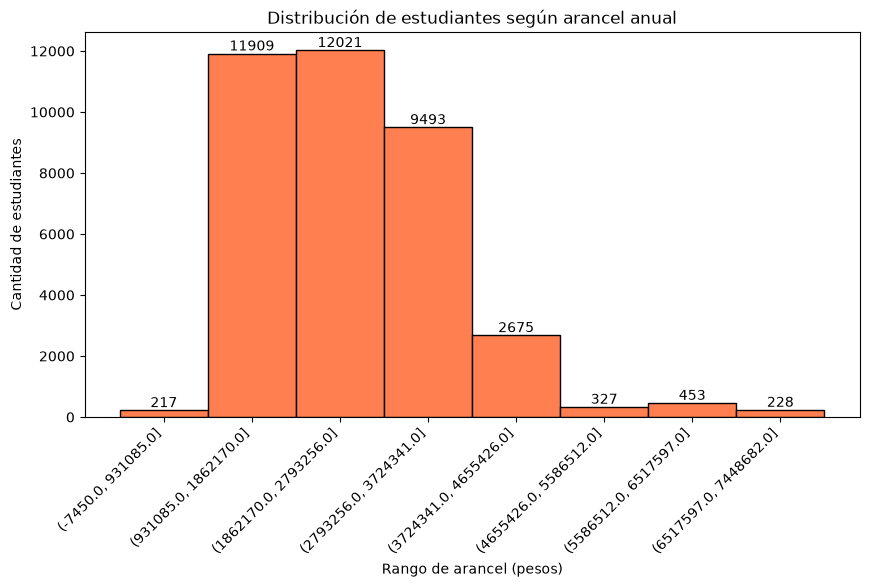

In [13]:
# Variables
categorias_arancel = tabla_arancel.index
f_arancel = tabla_arancel['Frecuencia absoluta']

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
barras_arancel = ax.bar(categorias_arancel.astype(str), f_arancel, color='coral', edgecolor='black', width=1)

# Personalización
ax.set_title('Distribución de estudiantes según arancel anual')
ax.set_xlabel('Rango de arancel (pesos)')
ax.set_ylabel('Cantidad de estudiantes')
ax.bar_label(barras_arancel)
plt.xticks(rotation=45, ha='right')

plt.show()


In [14]:
# Estadígrafos de Arancel
media_arancel = round(df['VALOR ARANCEL (PESOS)'].mean(), 0)
mediana_arancel = round(df['VALOR ARANCEL (PESOS)'].median(), 0)
moda_arancel = round(df['VALOR ARANCEL (PESOS)'].mode()[0], 0)
desv_arancel = round(df['VALOR ARANCEL (PESOS)'].std(), 0)
var_arancel = round(df['VALOR ARANCEL (PESOS)'].var(), 0)
q1_arancel = round(df['VALOR ARANCEL (PESOS)'].quantile(0.25), 0)
q3_arancel = round(df['VALOR ARANCEL (PESOS)'].quantile(0.75), 0)
iqr_arancel = round(q3_arancel - q1_arancel, 0)
cv_arancel = round((desv_arancel / media_arancel) * 100, 1)

resumen_arancel = pd.DataFrame({
    'Medida estadística': [
        'Media (Promedio)',
        'Mediana',
        'Moda',
        'Primer Cuartil (Q1 - 25%)',
        'Tercer Cuartil (Q3 - 75%)',
        'Rango Intercuartílico (IQR)',
        'Desviación Estándar',
        'Varianza',
        'Coeficiente de Variación (CV %)'
    ],
    'Valor en Pesos ($)': [
        f''.replace(',', '.'),
        f''.replace(',', '.'),
        f''.replace(',', '.'),
        f''.replace(',', '.'),
        f''.replace(',', '.'),
        f''.replace(',', '.'),
        f''.replace(',', '.'),
        f'{int(var_arancel):,}'.replace(',', '.'),
        f'{cv_arancel}%'
    ]
})

resumen_arancel


,Medida estadística,Valor en Pesos ($)
0,Media (Promedio),
1,Mediana,
2,Moda,
3,Primer Cuartil (Q1 - 25%),
4,Tercer Cuartil (Q3 - 75%),
5,Rango Intercuartílico (IQR),
6,Desviación Estándar,
7,Varianza,1.037.248.736.685
8,Coeficiente de Variación (CV %),41.0%


**Comentario e Interpretación de los Estadígrafos de Arancel:**  
- **Tendencia central:** 
  - El arancel **promedio (media)** es de **.484.899**, mientras que la **mediana** es de **.200.000**.
  - Al igual que en la edad, la media es sensiblemente más alta que la mediana, lo que revela una **fuerte asimetría positiva**. Existen carreras con aranceles muy elevados (que llegan hasta más de .400.000, como Medicina u Odontología) que inflan el promedio hacia arriba. Por esta razón, la **mediana (.200.000)** es el estadígrafo más representativo para describir el costo habitual de una carrera en la región.
- **Medidas de posición:**
  - El 25% de los aranceles más económicos no supera los **.698.000 ($)**, correspondiente mayoritariamente a carreras técnicas de CFT e IP.
  - El 50% de las carreras cuesta **.200.000 o menos (Mediana)**.
  - El 75% de las carreras cuesta hasta **.132.000 ($)**, lo que significa que el 25% superior de la matrícula regional paga aranceles entre ,1 y ,4 millones anuales.
- **Medidas de dispersión:**
  - El **rango intercuartílico ($) es de .434.000**, delimitando la dispersión del 50% central de los aranceles.
  - La **desviación estándar es de .018.454**, arrojando un **coeficiente de variación ($) del 41,0%**. Un $ mayor al 30% confirma que los aranceles tienen una **alta dispersión y heterogeneidad**, reflejando la enorme brecha económica entre carreras técnicas cortas y carreras profesionales universitarias de larga duración.


---
### Resumen de Cumplimiento de Requerimientos - Ítem 1

| Elemento Solicitado en Pauta | Herramienta Aplicada | Cumplimiento |
| :--- | :--- | :---: |
| **Gráficos** | Gráficos de barras (TIPO DE INSTITUCION, VALOR ARANCEL), circular (GENERO) e histograma (EDAD). |  Cumplido |
| **Tablas de frecuencia (una o más variables)** | Tablas univariadas (TIPO DE INSTITUCION, GENERO, EDAD, ARANCEL) y tabla bivariada cruzada (INSTITUCION vs GENERO). |  Cumplido |
| **Medidas de tendencia central** | Media, mediana y moda calculadas para EDAD y VALOR ARANCEL. |  Cumplido |
| **Percentiles / Cuartiles** |  (25\%)$, Mediana $ y  (75\%)$ calculados e interpretados. |  Cumplido |
| **Medidas de dispersión** | Desviación estándar, varianza, rango intercuartílico (IQR) y coeficiente de variación (CV). |  Cumplido |
| **Otros resúmenes e interpretación** | Frecuencias acumuladas (cumsum), análisis de asimetría, justificación de uso de mediana sobre la media y comentarios escritos en cada sección. |  Cumplido |
